In [1]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import shap
import scipy.integrate
scipy.integrate.simps = scipy.integrate.simpson



from itertools import product
import torch

sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.utils.kapplan_meir import k_m_cox
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_dataset_by_ids
from src.utils.set_seed import set_seed
from src.utils.cox_models import *
from sklearn.utils import resample


import numpy as np
import torch
import torchtuples as tt

%load_ext autoreload
%autoreload 2
%matplotlib inline

/Users/administrador/Library/Python/3.11/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
set_seed(42)

In [3]:
pp = Preprocessor()

In [4]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [5]:
df_merged = TorchPreprocessing(df_mRNA_raw_data,df_clinical_data, 23360).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

print(f"Samples: {comparation_df.shape[0]}, Genes: {comparation_df.shape[1]}")

Genes before Treshold: 20434
count    20434.000000
mean        73.977831
std        155.539160
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533
Samples: 519, Genes: 18534


In [6]:

import json

with open("splits.json") as f:
    _split = json.load(f)
trainval_ids = set(_split["train_ids"]) | set(_split["val_ids"])

top_genes_limma = pd.read_csv("elasticnet_candidates.csv")["gene"].tolist()
print(f"Loaded {len(top_genes_limma)} genes from train-only limma panel (test patients excluded)")


Loaded 1000 genes from train-only limma panel (test patients excluded)


In [7]:
N_GENES = len(top_genes_limma)
print(f"N_GENES = {N_GENES} (loaded from elasticnet_candidates.csv, train-only limma)")


N_GENES = 1000 (loaded from elasticnet_candidates.csv, train-only limma)


In [8]:
torch_preprocessing = TorchPreprocessing(df_mRNA_raw_data, df_clinical_data, 23360)
torch_preprocessing.genes_expression = top_genes_limma
genes_expression = top_genes_limma
X_scaled, durations, events, scaler, sample_ids = torch_preprocessing.get_data_set(60, return_ids=True)


Genes before Treshold: 1003
count    1003.000000
mean        0.546361
std         2.151125
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        24.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1003


In [9]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)



In [10]:
type(surival_data_set)

src.dataset.DataSet.SurvivalDataSet

In [11]:
import json
from src.dataset.split_data import split_dataset_by_ids

# Load the canonical split created by limma.ipynb so the NN uses the SAME patients.
split = json.load(open("splits.json"))
set_seed(42)
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_dataset_by_ids(
    surival_data_set, sample_ids,
    split["train_ids"], split["val_ids"], split["test_ids"]
)
print(f"Train: {train_X.shape[0]}, Val: {val_X.shape[0]}, Test: {test_X.shape[0]}")
print(f"Train: {type(train_X)}, Val: {type(val_X)}, Test: {type(test_X)}")

Train: 331, Val: 84, Test: 104
Train: <class 'torch.Tensor'>, Val: <class 'torch.Tensor'>, Test: <class 'torch.Tensor'>


In [12]:
in_features = train_X.shape[1]
train_X_np = train_X.cpu().numpy()
train_durations_np = train_durations.cpu().numpy()
train_events_np = train_events.cpu().numpy()



val_X_np = val_X.cpu().numpy()
val_durations_np = val_durations.cpu().numpy()
val_events_np = val_events.cpu().numpy()


test_X_np = test_X.cpu().numpy()
test_durations_np = test_durations.cpu().numpy()
test_events_np = test_events.cpu().numpy()

train_X_np.shape, train_durations_np.shape, train_events_np.shape

((331, 1000), (331,), (331,))

## DeepSurv Bootstrap

In [13]:
set_seed(42)
N_BOOTSTRAP = 50
gene_shap_records = {gene : [] for gene in genes_expression}

event_idx = np.where(train_events_np == 1)[0]
no_event_idx = np.where(train_events_np == 0)[0]
for i in range(N_BOOTSTRAP):
    # Re-seed each bootstrap so network init / training shuffling are deterministic.
    # Between-bootstrap variation comes only from the resample(random_state=i) draws.
    set_seed(42)
    idx_ev = resample(event_idx, random_state=i, replace=True)
    idx_no = resample(no_event_idx, random_state=i, replace=True)
    idx = np.concatenate([idx_ev, idx_no])
    
    X_boot = train_X_np[idx]
    dur_boot = train_durations_np[idx]
    ev_boot = train_events_np[idx]
    
    ev_boot_idx = np.where(ev_boot == 1)[0]
    no_ev_boot_idx = np.where(ev_boot == 0)[0]
    
    val_ev = resample(ev_boot_idx,    n_samples=max(3, int(0.15*len(ev_boot_idx))),    random_state=i, replace=False)
    val_no = resample(no_ev_boot_idx, n_samples=max(5, int(0.15*len(no_ev_boot_idx))), random_state=i, replace=False)
    val_idx = np.concatenate([val_ev, val_no])
    train_idx = np.setdiff1d(np.arange(len(X_boot)), val_idx)
    
    
    X_tr, X_val = X_boot[train_idx], X_boot[val_idx]
    dur_tr, dur_val = dur_boot[train_idx], dur_boot[val_idx]
    ev_tr,  ev_val = ev_boot[train_idx], ev_boot[val_idx]
    
    net_MLPVanilla = tt.torchtuples.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=[16, 16],
        dropout=0.2,
        batch_norm=True,
        output_bias=False,
        out_features=1
    )
    
    #DeepSurv
    model_boot = CoxPH(
        net_MLPVanilla,
        tt.torchtuples.optim.Adam(
            lr=0.0005,
            weight_decay=0.001 # type: ignore
        )
    )
    model_boot.fit(
        X_tr,
        (dur_tr, ev_tr),
        batch_size=256,
        epochs=200,
        verbose=False,
        callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=10)],
        val_data=(X_val, (dur_val, ev_val))
    )
    
    # Disable dropout + freeze BatchNorm running stats before SHAP.
    # In train mode every predict_fn call inside Permutation re-randomises
    # dropout and updates BN running mean/var, which makes the explanation
    # depend on call order and inflates between-bootstrap noise.
    model_boot.net.eval()
    
    def predict_fn(x):
        x_tensor = torch.tensor(x, dtype=torch.float32)
        with torch.no_grad():
            out = model_boot.net(x_tensor)
        return out.cpu().numpy().reshape(-1)


    preds_check = predict_fn(X_boot[:5])
    if np.isnan(preds_check).any():
        print(f"  → Bootstrap {i+1} divergió, saltando")
        continue

    background = shap.sample(X_boot, 50)
    explainer = shap.explainers.Permutation(
        predict_fn, background,
        feature_names=genes_expression,
        max_evals=2001
    )
    shap_values = explainer(test_X_np)
    mean_abs = np.abs(shap_values.values).mean(axis=0)

    for j, gene in enumerate(genes_expression):
        gene_shap_records[gene].append(mean_abs[j])

    print(f"Bootstrap {i+1}/{N_BOOTSTRAP} OK")
    with open("shap_bootstrap_checkpoint.json", "w") as f:
      json.dump(gene_shap_records, f)


PermutationExplainer explainer: 105it [03:01,  1.76s/it]                         


Bootstrap 1/50 OK


PermutationExplainer explainer: 105it [02:54,  1.78s/it]                         


Bootstrap 2/50 OK


PermutationExplainer explainer: 105it [03:03,  1.86s/it]                         


...

Bootstrap 48/50 OK


PermutationExplainer explainer: 105it [02:56,  1.81s/it]                         


Bootstrap 49/50 OK


PermutationExplainer explainer: 105it [03:01,  1.86s/it]                         

Bootstrap 50/50 OK


In [27]:
gene_shap_records['ZBTB46']



[0.0066008318641867835,
 0.006092968711342945,
 0.006361605804950863,
 0.006512665876115742,
 0.006386438728345987,
 0.007500482750877454,
 0.006306238489655342,
 0.006114443852834833,
 0.007315639373309047,
 0.006828241623185858,
 0.005680996813059141,
 0.006116338127400157,
 0.005815008786918886,
 0.007102249364117878,
 0.007771278183208784,
 0.007038104743965405,
 0.005965321135187811,
 0.007654271407966293,
 0.006535404075223663,
 0.006147374567271279,
 0.008021583310686625,
 0.007397371230270854,
 0.006732262023724617,
 0.0062102565302764295,
 0.009165880296719619,
 0.007540925931221307,
 0.007601391377393162,
 0.00636115250034401,
 0.006444178527543462,
 0.007004726788011164,
 0.008473750194176457,
 0.007696590707995565,
 0.006298547312527752,
 0.007841048649368954,
 0.00694627814854567,
 0.008619501914363356,
 0.008820527439328053,
 0.008090214941095408,
 0.006239737384469034,
 0.009056761217339393,
 0.006997527560183353,
 0.007863991548432607,
 0.009201378972950173,
 0.00772174

In [15]:
valid_genes = [g for g in genes_expression if len(gene_shap_records[g]) > 0]

records   = np.array([gene_shap_records[g] for g in valid_genes])   # (genes, n_boot)
mean_shap = records.mean(axis=1)
std_shap  = records.std(axis=1)

# Estabilidad real: coeficiente de variación (menor = más estable)
cv_shap = np.where(mean_shap > 0, std_shap / mean_shap, np.nan)

# Frecuencia de aparición en el top-50 a lo largo de los bootstraps
TOP_K = 50
topk_freq = np.zeros(len(valid_genes))
for b in range(records.shape[1]):
    top_idx = np.argsort(-records[:, b])[:TOP_K]
    topk_freq[top_idx] += 1
topk_freq /= max(records.shape[1], 1)

bootstrap_df = pd.DataFrame({
    'gene':      valid_genes,
    'mean_shap': mean_shap,
    'std_shap':  std_shap,
    'cv_shap':   cv_shap,
    'topk_freq': topk_freq,
}).sort_values('mean_shap', ascending=False)

boot_to_csv = bootstrap_df.head(500)
boot_to_csv.to_csv("boot_strap_df_deepsurv.csv")

In [31]:
boot_to_csv

,gene,mean_shap,std_shap,cv_shap,topk_freq
69,RBMS3,0.034900,0.003448,0.098806,1.0
173,SERPINA5,0.032932,0.003432,0.104218,1.0
460,HAND2-AS1,0.032775,0.003306,0.100862,1.0
979,MFSD6,0.029653,0.002152,0.072584,1.0
151,SNRPF,0.028408,0.003138,0.110476,1.0
...,...,...,...,...,...
243,MIPOL1,0.007155,0.000968,0.135353,0.0
6,TMSB15B,0.007151,0.001322,0.184818,0.0
758,YY1,0.007150,0.001176,0.164454,0.0
784,C4orf48,0.007149,0.001642,0.229699,0.0


### CoxNett DeppSurv

In [28]:
set_seed(42)
N_BOOTSTRAP = 50
gene_shap_records_coxnnet = {gene : [] for gene in genes_expression}

event_idx = np.where(train_events_np == 1)[0]
no_event_idx = np.where(train_events_np == 0)[0]
for i in range(N_BOOTSTRAP):
    # Re-seed each bootstrap so network init / training shuffling are deterministic.
    # Between-bootstrap variation comes only from the resample(random_state=i) draws.
    set_seed(42)
    idx_ev = resample(event_idx, random_state=i, replace=True)
    idx_no = resample(no_event_idx, random_state=i, replace=True)
    idx = np.concatenate([idx_ev, idx_no])
    
    X_boot = train_X_np[idx]
    dur_boot = train_durations_np[idx]
    ev_boot = train_events_np[idx]
    
    ev_boot_idx = np.where(ev_boot == 1)[0]
    no_ev_boot_idx = np.where(ev_boot == 0)[0]
    
    val_ev = resample(ev_boot_idx,    n_samples=max(3, int(0.15*len(ev_boot_idx))),    random_state=i, replace=False)
    val_no = resample(no_ev_boot_idx, n_samples=max(5, int(0.15*len(no_ev_boot_idx))), random_state=i, replace=False)
    val_idx = np.concatenate([val_ev, val_no])
    train_idx = np.setdiff1d(np.arange(len(X_boot)), val_idx)
    
    
    X_tr, X_val = X_boot[train_idx], X_boot[val_idx]
    dur_tr, dur_val = dur_boot[train_idx], dur_boot[val_idx]
    ev_tr,  ev_val = ev_boot[train_idx], ev_boot[val_idx]
    
    net_MLPVanilla = tt.torchtuples.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=[32],
        dropout=0.2,
        batch_norm=True,
        output_bias=False,
        out_features=1
    )
    
    #DeepSurv
    model_boot = CoxPH(
        net_MLPVanilla,
        tt.torchtuples.optim.Adam(
            lr=0.0001,
            weight_decay=0.0001 # type: ignore
        )
    )
    model_boot.fit(
        X_tr,
        (dur_tr, ev_tr),
        batch_size=256,
        epochs=200,
        verbose=False,
        callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=10)],
        val_data=(X_val, (dur_val, ev_val))
    )
    
    # Disable dropout + freeze BatchNorm running stats before SHAP.
    # In train mode every predict_fn call inside Permutation re-randomises
    # dropout and updates BN running mean/var, which makes the explanation
    # depend on call order and inflates between-bootstrap noise.
    model_boot.net.eval()
    
    def predict_fn(x):
        x_tensor = torch.tensor(x, dtype=torch.float32)
        with torch.no_grad():
            out = model_boot.net(x_tensor)
        return out.cpu().numpy().reshape(-1)


    preds_check = predict_fn(X_boot[:5])
    if np.isnan(preds_check).any():
        print(f"  → Bootstrap {i+1} divergió, saltando")
        continue

    background = shap.sample(X_boot, 50)
    explainer = shap.explainers.Permutation(
        predict_fn, background,
        feature_names=genes_expression,
        max_evals=2001
    )
    shap_values = explainer(test_X_np)
    mean_abs = np.abs(shap_values.values).mean(axis=0)

    for j, gene in enumerate(genes_expression):
        gene_shap_records_coxnnet[gene].append(mean_abs[j])

    print(f"Bootstrap {i+1}/{N_BOOTSTRAP} OK")
    with open("shap_bootstrap_coxnnet_checkpoint.json", "w") as f:
      json.dump(gene_shap_records_coxnnet, f)


PermutationExplainer explainer: 105it [03:10,  1.91s/it]                         


Bootstrap 1/50 OK


PermutationExplainer explainer: 105it [03:04,  1.86s/it]                         


Bootstrap 2/50 OK


PermutationExplainer explainer: 105it [03:05,  1.87s/it]                         


...

Bootstrap 48/50 OK


PermutationExplainer explainer: 105it [03:20,  2.00s/it]                         


Bootstrap 49/50 OK


PermutationExplainer explainer: 105it [03:05,  1.89s/it]                         

Bootstrap 50/50 OK


In [29]:
valid_genes = [g for g in gene_shap_records_coxnnet if len(gene_shap_records_coxnnet[g]) > 0]

records   = np.array([gene_shap_records_coxnnet[g] for g in valid_genes])   # (genes, n_boot)
mean_shap = records.mean(axis=1)
std_shap  = records.std(axis=1)

cv_shap = np.where(mean_shap > 0, std_shap / mean_shap, np.nan)

TOP_K = 50
topk_freq = np.zeros(len(valid_genes))
for b in range(records.shape[1]):
    top_idx = np.argsort(-records[:, b])[:TOP_K]
    topk_freq[top_idx] += 1
topk_freq /= max(records.shape[1], 1)

bootstrap_df_coxnnet = pd.DataFrame({'gene': valid_genes, 'mean_shap': mean_shap,'std_shap':  std_shap, 'cv_shap':   cv_shap, 'topk_freq': topk_freq,
}).sort_values('mean_shap', ascending=False)

boot_to_csv_coxnnet = bootstrap_df_coxnnet.head(500)
boot_to_csv_coxnnet.to_csv("boot_strap_df_coxnnet.csv")

In [30]:
boot_to_csv_coxnnet

,gene,mean_shap,std_shap,cv_shap,topk_freq
195,SGPP1,0.035950,0.001877,0.052205,1.0
55,GLI1,0.034748,0.002447,0.070410,1.0
199,PDCD4,0.032524,0.002147,0.066009,1.0
260,FLOT1,0.030933,0.001920,0.062064,1.0
789,SCRN3,0.029265,0.001422,0.048587,1.0
...,...,...,...,...,...
999,RPL35,0.007082,0.001046,0.147741,0.0
528,FTH1P3,0.007073,0.000773,0.109222,0.0
936,RARRES1,0.007024,0.002223,0.316448,0.0
483,VPS51,0.006958,0.000882,0.126752,0.0


### Consensus of the genes

In [32]:
df_coxnnet = pd.read_csv("boot_strap_df_coxnnet.csv")
df_deepsurv = pd.read_csv("boot_strap_df_deepsurv.csv")
df_elasticnet = pd.read_csv("elasticnet_genes.csv")

STABILIZER = 0.1

df_coxnnet_genes = set(df_coxnnet.loc[df_coxnnet["topk_freq"] >= STABILIZER]["gene"])
df_deepsurv_genes = set(df_deepsurv.loc[df_deepsurv["topk_freq"] >= STABILIZER]["gene"])

enet_selected   = set(pd.read_csv("elasticnet_genes.csv")["gene"])
enet_candidates = set(pd.read_csv("elasticnet_candidates.csv")["gene"])

consenso = df_coxnnet_genes & df_deepsurv_genes & enet_selected


solo_no_lineal = (df_coxnnet_genes & df_deepsurv_genes & enet_candidates) - enet_selected

consenso

{'KIAA0895L'}

In [33]:
TOPN = 100
df_coxnnet_genes  = set(df_coxnnet.head(TOPN)["gene"])
df_deepsurv_genes = set(df_deepsurv.head(TOPN)["gene"])

enet_selected   = set(pd.read_csv("elasticnet_genes.csv")["gene"])
enet_candidates = set(pd.read_csv("elasticnet_candidates.csv")["gene"])

nn_consenso = set(df_coxnnet.head(100)["gene"]) | set(df_deepsurv.head(100)["gene"])        
consenso = nn_consenso & enet_selected # el modelo lineal es tan disperso que el consenso de todos los modelos se reduce a casi nada                
solo_no_lineal = (nn_consenso & enet_candidates) - enet_selected

print(f"NN consenso: {len(nn_consenso)} -> {sorted(nn_consenso)}")
print(f"Consenso total: {len(consenso)} -> {sorted(consenso)}")
print(f"Solo no lineales: {len(solo_no_lineal)} -> {sorted(solo_no_lineal)}")

consenso


NN consenso: 187 -> ['ABI2', 'ACACB', 'ACTA2', 'ACTG1P4', 'ACVR1C', 'ADAT1', 'AGO2', 'AK4', 'ARHGEF3', 'ARMCX3', 'ATG3', 'ATHL1', 'ATP13A1', 'AURKB', 'B4GALT3', 'BBS4', 'BTG1', 'C1GALT1', 'C7', 'CAD', 'CASKIN2', 'CCDC47', 'CD28', 'CDK5RAP1', 'CDK7', 'CFAP298', 'CHST8', 'CLPB', 'CNN3', 'COL8A2', 'COMMD4', 'COX7A1', 'CPNE7', 'CSNK1A1', 'DCN', 'DDX3X', 'DHX30', 'DNAJC25', 'EFHD1', 'EIF4A3', 'ESRP2', 'F2RL2', 'FASTK', 'FBXL5', 'FGF18', 'FLOT1', 'FYTTD1', 'GABPB1-AS1', 'GATD3A', 'GLA', 'GLI1', 'GLT8D2', 'GNG12', 'GOLGA5', 'GPR65', 'GTF2H3', 'HAND2-AS1', 'HIST1H2BE', 'HNRNPR', 'HNRNPUL1', 'HTRA3', 'IDI1', 'IL17RA', 'IMPDH2', 'IQSEC2', 'ISCA2', 'ITGBL1', 'KCNK13', 'KIAA0895L', 'KLC3', 'LCA5L', 'LILRA2', 'LINC02904', 'LNX1', 'LRBA', 'LTBP3', 'LTBP4', 'LTN1', 'MAP3K10', 'MFSD6', 'MGAT3', 'MGEA5', 'MROH8', 'MRPL50', 'MSL2', 'MTFR1', 'MTFR1L', 'MTMR6', 'MYCT1', 'NAT6', 'NGFR', 'NINL', 'NLRP1', 'NT5C3B', 'OLFML2B', 'OSGEPL1', 'OXNAD1', 'PALMD', 'PDCD4', 'PEX11B', 'PHF20L1', 'PHYKPL', 'PIGQ', 'PKNO

{'KIAA0895L', 'TNPO2'}

In [34]:
import gseapy as gp
import pandas as pd
from gseapy import dotplot, barplot
gene_list  = sorted(solo_no_lineal)
background = sorted(enet_candidates)
libs = ["KEGG_2021_Human", "GO_Biological_Process_2023", "Reactome_2022"]
gene_sets = {lib: gp.get_library(name=lib, organism="human") for lib in libs}

In [35]:
frames = []
for lib, sets in gene_sets.items():
    enr = gp.enrich(                
        gene_list=gene_list,
        gene_sets=sets,
        background=background,        
        outdir=None,
    )
    df = enr.results.copy()
    df["Gene_set"] = lib
    frames.append(df)

res = pd.concat(frames, ignore_index=True)

In [36]:
# Control de nomenclatura: cuántos genes mapearon
mapeados = set()
for g in res["Genes"].dropna():
    mapeados.update(s.strip() for s in g.split(";"))
no_mapeados = set(gene_list) - mapeados
print(f"{len(mapeados)} mapearon; {len(no_mapeados)} no aparecen en ningún término")
if no_mapeados:
    print("No mapeados:", sorted(no_mapeados))

# Significativos: FDR (Benjamini-Hochberg) < 0.05 sobre las 3 librerías (res, no solo la última)
sig = (res[res["P-value"] < 0.05]
       .sort_values(["Gene_set", "Adjusted P-value"])
       .reset_index(drop=True))
print(f"{len(sig)} términos con FDR < 0.05")

passed_values = res[res["P-value"] < 0.05]
print(passed_values["P-value"])

151 mapearon; 34 no aparecen en ningún término
No mapeados: ['ACTG1P4', 'ATHL1', 'CASKIN2', 'DNAJC25', 'EFHD1', 'GABPB1-AS1', 'GATD3A', 'GLT8D2', 'HAND2-AS1', 'HIST1H2BE', 'HTRA3', 'LCA5L', 'LINC02904', 'MGEA5', 'MROH8', 'MYCT1', 'NAT6', 'OLFML2B', 'OXNAD1', 'PALMD', 'PLEKHS1', 'PP7080', 'SCRN3', 'SDR39U1', 'SLC25A5-AS1', 'SMIM12', 'SNHG6', 'TC2N', 'TEN1', 'TMEM194A', 'TSGA10', 'ZBED8', 'ZNF300P1', 'ZNF815P']
54 términos con FDR < 0.05
17      0.034074
18      0.046616
31      0.006248
131     0.034074
172     0.034074
209     0.034074
214     0.021571
216     0.021571
268     0.034074
291     0.034074
318     0.042872
325     0.021571
326     0.034074
367     0.034074
392     0.046616
413     0.034074
445     0.034074
492     0.024999
560     0.034074
588     0.034074
598     0.034074
601     0.024999
605     0.034074
630     0.006248
654     0.034074
687     0.034074
824     0.021571
934     0.024323
935     0.034074
936     0.042872
943     0.034074
1020    0.021571
1061    0.046616

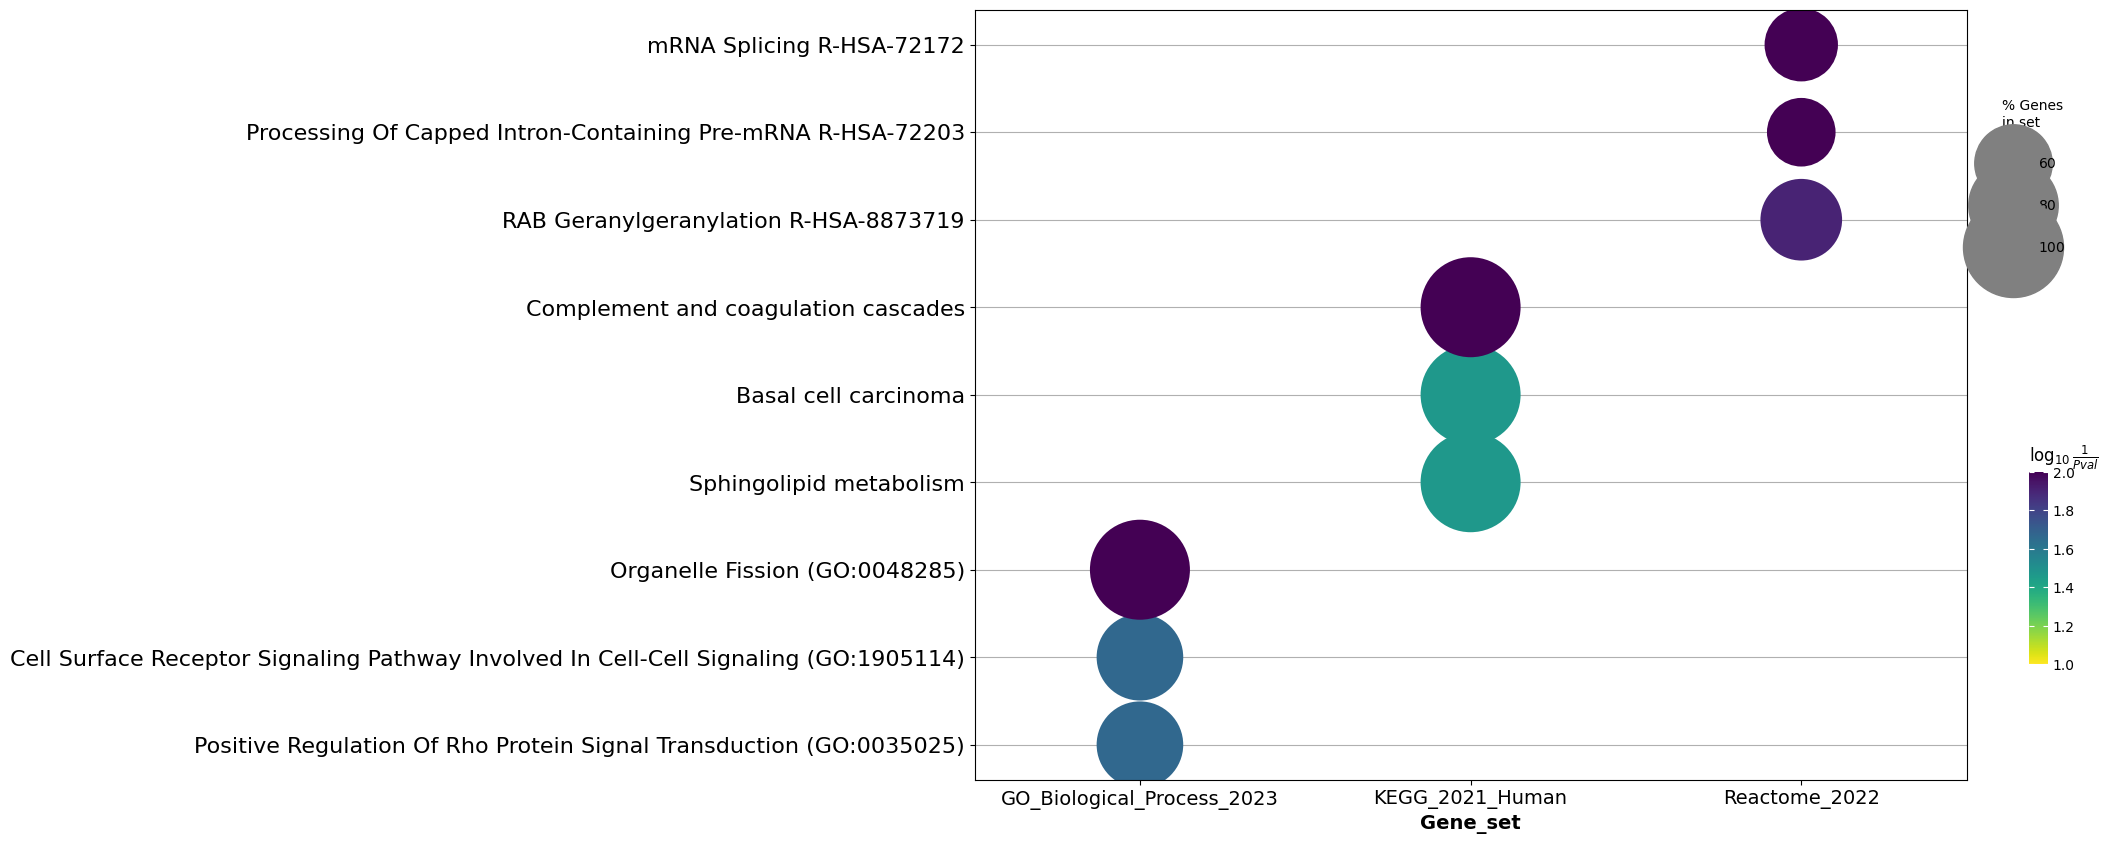

In [37]:
passed_values = (
    passed_values
    .sort_values("P-value")
    .groupby("Gene_set")
    .head(3)
)

ax = dotplot(
    passed_values,
    column="P-value",
    x="Gene_set",
    size=12,
    top_term=5,
    figsize=(16,10),
)


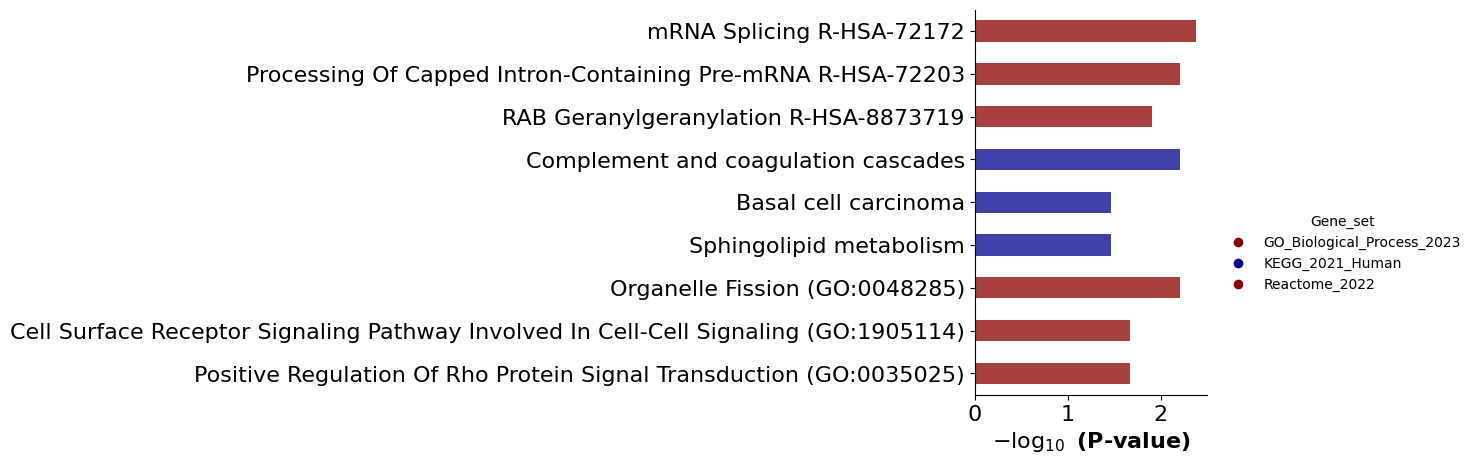

In [38]:
ax = barplot(passed_values,
              column="P-value",
              group='Gene_set', 
              size=10,
              top_term=5,
              figsize=(3,5),
              color=['darkred', 'darkblue'] # set colors for group
              )

## g) Pares de genes que interaccionan sinérgicamente con el pronóstico

Modelo: **Cox-nnet** (pycox `CoxPH`), cargado desde `CoxNnet_weights.pt`. Dos métodos:

- **Método 1 — Permutación de pares** (principal): mide la sinergia real como
  `interacción = drop_conjunto − drop_i − drop_j` (análogo por permutación del H-statistic).
  Un par con `interacción > 0` aporta al pronóstico más junto que por separado.
- **Método 2 — SHAP `potential_interactions`** (contraste): para cada gen lista sus socios de interacción.

La arquitectura del modelo se **infiere automáticamente** del `.pt` (`infer_arch_from_weights`), así que no hay que ajustarla a mano aunque cambie `best_params_cn` en `nn_Cox_limma.ipynb`.

In [52]:
"""
Apartado g) Pares de genes que interaccionan SINÉRGICAMENTE con el pronóstico.
Modelo: Cox-nnet (pycox CoxPH), cargado desde CoxNnet_weights.pt.

  MÉTODO 1 - Permutación de pares (principal): mide sinergia real como
             interaccion = drop_conjunto - drop_i - drop_j (análogo del H-statistic).
  MÉTODO 2 - SHAP potential_interactions (contraste): socios de interacción por gen.

La arquitectura se INFIERE del .pt (infer_arch_from_weights), no hay que ajustarla
a mano aunque cambie best_params_cn en nn_Cox_limma.ipynb.
Requiere en memoria: genes_expression, in_features, train_X_np, test_X_np,
test_durations, test_events y (opcional) solo_no_lineal. Usa el `tt` ya importado.
"""

import re
import numpy as np
import pandas as pd
import torch
import shap
from pycox.models.cox import CoxPH

# C-index basado en el score de riesgo (no necesita baseline hazards).
try:
    from sksurv.metrics import concordance_index_censored
    def cindex(events_bool, durations, risk):
        return concordance_index_censored(events_bool, durations, risk)[0]
except Exception:
    from lifelines.utils import concordance_index
    def cindex(events_bool, durations, risk):
        # lifelines: score alto = mayor supervivencia -> negamos el riesgo
        return concordance_index(durations, -risk, events_bool.astype(int))



SEED = 42
N_REPEATS = 30    
K_CANDIDATES = 25  


def _np(a):
    if torch.is_tensor(a):
        return a.detach().cpu().numpy()
    return np.asarray(a)


def infer_arch_from_weights(weights_path):
    """Deduce num_nodes y batch_norm del state_dict guardado. dropout no se puede
    inferir (no tiene parámetros) y es irrelevante en modo eval."""
    sd = torch.load(weights_path, map_location="cpu")
    if hasattr(sd, "state_dict"):
        sd = sd.state_dict()
    hidden, has_bn = {}, False
    for k, v in sd.items():
        m = re.match(r"net\.(\d+)\.linear\.weight$", k)
        if m:
            hidden[int(m.group(1))] = int(v.shape[0])
        if ".batch_norm." in k:
            has_bn = True
    return dict(num_nodes=[hidden[i] for i in sorted(hidden)], batch_norm=has_bn, dropout=0.0)


def make_predict_fn(model):
    model.net.eval()
    def predict_fn(x):
        x_tensor = torch.as_tensor(np.asarray(x, dtype=np.float32))
        with torch.no_grad():
            out = model.net(x_tensor)
        return out.cpu().numpy().reshape(-1)
    return predict_fn



def build_candidates(gene_names, coxnnet_csv="boot_strap_df_coxnnet.csv",
                     extra_genes=None, k=25):
    """Top-k del CSV Cox-nnet (estabilidad/magnitud) unidos a solo_no_lineal."""
    name_set = set(gene_names)
    cands = []
    try:
        df = pd.read_csv(coxnnet_csv)
        sort_cols = [c for c in ["topk_freq", "mean_shap"] if c in df.columns]
        if sort_cols:
            df = df.sort_values(sort_cols, ascending=False)
        cands = [g for g in df["gene"].tolist() if g in name_set][:k]
    except Exception as e:
        print(f"[aviso] no pude leer {coxnnet_csv}: {e}")
    if extra_genes:
        for g in extra_genes:
            if g in name_set and g not in cands:
                cands.append(g)
    return cands

def permutation_pair_interactions(model, X, events_bool, durations, gene_names,
                                  candidates, n_repeats=50, seed=42):
    """Sinergia por par CON incertidumbre. En cada repetición se usa UNA misma
    permutación para i, j y el par, y se calcula inter_r = d_ij_r - d_i_r - d_j_r.
    Devuelve por par: interaccion (media), inter_std, z = media/SE, p-valor
    (una cola, H1: inter>0) y FDR (Benjamini-Hochberg). Así se distingue una
    sinergia real del ruido de permutación."""
    from scipy.stats import norm
    predict_fn = make_predict_fn(model)
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[0]
    name_to_col = {g: k for k, g in enumerate(gene_names)}
    cand = [g for g in candidates if g in name_to_col]
    col = {g: name_to_col[g] for g in cand}
    rng = np.random.default_rng(seed)

    c0 = cindex(events_bool, durations, predict_fn(X))

    # Una permutación por repetición, COMPARTIDA entre genes y pares.
    perms = [rng.permutation(n) for _ in range(n_repeats)]

    # Caída individual por repetición -> array (n_repeats,)
    d_single = {}
    for g in cand:
        cg = col[g]
        arr = np.empty(n_repeats)
        for r, perm in enumerate(perms):
            Xp = X.copy()
            Xp[:, cg] = X[perm, cg]
            arr[r] = c0 - cindex(events_bool, durations, predict_fn(Xp))
        d_single[g] = arr

    rows = []
    for a in range(len(cand)):
        for b in range(a + 1, len(cand)):
            gi, gj = cand[a], cand[b]
            ci, cj = col[gi], col[gj]
            inter_r = np.empty(n_repeats)
            dij_r   = np.empty(n_repeats)
            for r, perm in enumerate(perms):
                Xp = X.copy()
                Xp[:, ci] = X[perm, ci]
                Xp[:, cj] = X[perm, cj]
                dij_r[r]   = c0 - cindex(events_bool, durations, predict_fn(Xp))
                inter_r[r] = dij_r[r] - d_single[gi][r] - d_single[gj][r]
            mean = float(inter_r.mean())
            sd   = float(inter_r.std(ddof=1))
            se   = sd / np.sqrt(n_repeats) if sd > 0 else 0.0
            z    = mean / se if se > 0 else 0.0
            rows.append((gi, gj, float(d_single[gi].mean()), float(d_single[gj].mean()),
                         float(dij_r.mean()), mean, sd, z))

    out = pd.DataFrame(rows, columns=["gen_i", "gen_j", "drop_i", "drop_j",
                                      "drop_conjunto", "interaccion", "inter_std", "z"])
    # p-valor una cola (H1: interaccion > 0) y FDR Benjamini-Hochberg
    out["p_value"] = norm.sf(out["z"].values)
    out = out.sort_values("p_value").reset_index(drop=True)
    m = len(out)
    raw = out["p_value"].values * m / np.arange(1, m + 1)
    out["fdr"] = np.clip(np.minimum.accumulate(raw[::-1])[::-1], 0, 1)
    return c0, out.sort_values("z", ascending=False).reset_index(drop=True)

def _rank_partners(sv, col, candidate_cols):
    """Socios de interacción de la columna col (solo candidatos). Robusto a versiones de SHAP."""
    try:
        order = list(shap.utils.potential_interactions(sv[:, col], sv))
    except Exception:
        try:
            order = list(shap.utils.approximate_interactions(col, sv.values, sv.data))
        except Exception:
            shap_i, feats, scores = sv.values[:, col], sv.data, []
            for k in range(feats.shape[1]):
                if k == col:
                    scores.append(-np.inf); continue
                c = np.corrcoef(shap_i, feats[:, k])[0, 1]
                scores.append(abs(c) if np.isfinite(c) else 0.0)
            order = list(np.argsort(scores)[::-1])
    return [k for k in order if k in candidate_cols and k != col]


def shap_pair_interactions(model, background_X, explain_X, gene_names, candidates,
                           n_background=50, max_evals=2001, top_partners=5):
    """Recalcula UNA explanation SHAP y lista, por gen candidato, sus socios."""
    predict_fn = make_predict_fn(model)
    bg = shap.sample(np.asarray(background_X, dtype=np.float32), n_background)
    explainer = shap.explainers.Permutation(
        predict_fn, bg, feature_names=list(gene_names), max_evals=max_evals
    )
    sv = explainer(np.asarray(explain_X, dtype=np.float32))
    name_to_col = {g: k for k, g in enumerate(gene_names)}
    cand_cols = {name_to_col[g] for g in candidates if g in name_to_col}
    rows = []
    for g in candidates:
        if g not in name_to_col:
            continue
        for rank, k_idx in enumerate(_rank_partners(sv, name_to_col[g], cand_cols)[:top_partners]):
            rows.append((g, gene_names[k_idx], rank + 1))
    return sv, pd.DataFrame(rows, columns=["gen", "socio", "rank_interaccion"])

In [43]:
test_X = np.array(test_X).astype('float32')
test_durations = np.array(test_durations).flatten()
test_events = np.array(test_events).astype(bool).flatten()

print(f"test_X shape: {test_X.shape}")
print(f"test_durations shape: {test_durations.shape}")
print(f"test_events shape: {test_events.shape}")

test_X shape: (104, 1000)
test_durations shape: (104,)
test_events shape: (104,)


In [44]:
net_cn = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features,
    num_nodes=[64],
    out_features=1,
    batch_norm=True,
    dropout=0
)

model_cn = CoxPH(net_cn, tt.torchtuples.optim.Adam(
    lr=0.001, weight_decay=0.001
))
model_cn.fit(
    input=train_X, target=(train_durations, train_events),
    batch_size=128, epochs=200, verbose=True,
    callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=30)],
    val_data=(val_X, (val_durations, val_events)),
)

model_cn.compute_baseline_hazards()
surv_cn = model_cn.predict_surv_df(test_X)
ev_cn   = EvalSurv(surv_cn, test_durations, test_events, censor_surv='km')

ci_test_coxnnet = ev_cn.concordance_td()


0:	[0s / 0s],		train_loss: 4.2119,	val_loss: 3.4469
1:	[0s / 0s],		train_loss: 3.1976,	val_loss: 3.4893
2:	[0s / 0s],		train_loss: 2.7672,	val_loss: 3.5013
3:	[0s / 0s],		train_loss: 2.1642,	val_loss: 3.4866
4:	[0s / 0s],		train_loss: 1.9617,	val_loss: 3.4758
5:	[0s / 0s],		train_loss: 1.8953,	val_loss: 3.4711
6:	[0s / 0s],		train_loss: 1.6193,	val_loss: 3.4592
7:	[0s / 0s],		train_loss: 1.5047,	val_loss: 3.4272
8:	[0s / 0s],		train_loss: 1.3589,	val_loss: 3.3932
9:	[0s / 0s],		train_loss: 1.2355,	val_loss: 3.3773
10:	[0s / 0s],		train_loss: 1.1324,	val_loss: 3.3874
11:	[0s / 0s],		train_loss: 1.1355,	val_loss: 3.4267
12:	[0s / 0s],		train_loss: 0.9587,	val_loss: 3.4543
13:	[0s / 0s],		train_loss: 0.9565,	val_loss: 3.4621
14:	[0s / 0s],		train_loss: 0.9261,	val_loss: 3.4311
15:	[0s / 0s],		train_loss: 0.9191,	val_loss: 3.3868
16:	[0s / 0s],		train_loss: 0.8051,	val_loss: 3.3611
17:	[0s / 0s],		train_loss: 0.7522,	val_loss: 3.3752
18:	[0s / 0s],		train_loss: 0.7896,	val_loss: 3.3952
19:

In [45]:
print(f"C-index test  Cox-nnet : {ci_test_coxnnet:.4f}  capas: {[64]}")

C-index test  Cox-nnet : 0.8777  capas: [64]


In [53]:
# permutación de pares (principal)  
events_bool = _np(test_events).astype(bool)
durations   = _np(test_durations).astype(float)


candidates = build_candidates(
    genes_expression,
    coxnnet_csv="boot_strap_df_coxnnet.csv",
    extra_genes=sorted(solo_no_lineal) if "solo_no_lineal" in dir() else None,
    k=K_CANDIDATES,
)
print(f"{len(candidates)} genes candidatos: {candidates}")

c0, pares = permutation_pair_interactions(
    model_cn, test_X_np, events_bool, durations, genes_expression,
    candidates, n_repeats=N_REPEATS, seed=SEED,
)
print(f"\nC-index base del modelo: {c0:.4f}")
n_sig = int((pares["fdr"] < 0.05).sum())
print(f"Pares con FDR < 0.05 (sinergia significativa): {n_sig} de {len(pares)}")
print("\nTop 20 pares por z (interaccion / error estándar):")
cols = ["gen_i", "gen_j", "interaccion", "inter_std", "z", "p_value", "fdr"]
print(pares[cols].head(20).to_string(index=False))
pares.to_csv("g_pares_permutacion.csv", index=False)

185 genes candidatos: ['SGPP1', 'GLI1', 'PDCD4', 'FLOT1', 'SCRN3', 'FASTK', 'BBS4', 'PHYKPL', 'PLXND1', 'UBE2L3', 'ZFPM2', 'SNRPF', 'NGFR', 'CLPB', 'ARMCX3', 'LCA5L', 'MRPL50', 'ZNF682', 'SYNDIG1', 'LILRA2', 'RAB5B', 'UHMK1', 'VPS36', 'OXNAD1', 'LTN1', 'ABI2', 'ACACB', 'ACTA2', 'ACTG1P4', 'ACVR1C', 'ADAT1', 'AGO2', 'AK4', 'ARHGEF3', 'ATG3', 'ATHL1', 'ATP13A1', 'AURKB', 'B4GALT3', 'BTG1', 'C1GALT1', 'C7', 'CAD', 'CASKIN2', 'CCDC47', 'CD28', 'CDK5RAP1', 'CDK7', 'CFAP298', 'CHST8', 'CNN3', 'COL8A2', 'COMMD4', 'COX7A1', 'CPNE7', 'CSNK1A1', 'DCN', 'DDX3X', 'DHX30', 'DNAJC25', 'EFHD1', 'EIF4A3', 'ESRP2', 'F2RL2', 'FBXL5', 'FGF18', 'FYTTD1', 'GABPB1-AS1', 'GATD3A', 'GLA', 'GLT8D2', 'GNG12', 'GOLGA5', 'GPR65', 'GTF2H3', 'HAND2-AS1', 'HIST1H2BE', 'HNRNPR', 'HNRNPUL1', 'HTRA3', 'IDI1', 'IL17RA', 'IMPDH2', 'IQSEC2', 'ISCA2', 'ITGBL1', 'KCNK13', 'KLC3', 'LINC02904', 'LNX1', 'LRBA', 'LTBP3', 'LTBP4', 'MAP3K10', 'MFSD6', 'MGAT3', 'MGEA5', 'MROH8', 'MSL2', 'MTFR1', 'MTFR1L', 'MTMR6', 'MYCT1', 'NAT6',

In [47]:
# SHAP potential_interactions (contraste)
sv, shap_pairs = shap_pair_interactions(
    model_cn, train_X_np, test_X_np, genes_expression, candidates,
)
print("Socios de interacción según SHAP:")
print(shap_pairs.head(20).to_string(index=False))
shap_pairs.to_csv("g_pares_shap.csv", index=False)

PermutationExplainer explainer: 105it [03:37,  2.17s/it]                         


Socios de interacción según SHAP:
  gen     socio  rank_interaccion
SGPP1   ZKSCAN2                 1
SGPP1      ATG3                 2
SGPP1    ACVR1C                 3
SGPP1      GLI1                 4
SGPP1   SLC35A2                 5
 GLI1 LINC02904                 1
 GLI1     SMYD4                 2
 GLI1      TAF2                 3
 GLI1   CFAP298                 4
 GLI1   TUBGCP3                 5
PDCD4        C7                 1
PDCD4    TARDBP                 2
PDCD4    ACVR1C                 3
PDCD4    ZNF616                 4
PDCD4   B4GALT3                 5
FLOT1     VEGFB                 1
FLOT1     UHRF2                 2
FLOT1      NGFR                 3
FLOT1     SMYD4                 4
FLOT1     EFHD1                 5


In [55]:
import requests
from io import StringIO
import pandas as pd

# ====================== CONFIG h) ======================
STRING_API   = "https://string-db.org/api"
SPECIES      = 9606            # humano
NETWORK_TYPE = "physical"      # PPI física (enunciado). Alternativa: "functional"
SCORE_THR    = 0.4             # confianza media de STRING (0.4 = score 400)
CALLER       = "tfg_brca_shap"
FDR_THR      = 0.05
# =======================================================

# 1) Pares significativos de g)
pares = pd.read_csv("g_pares_permutacion.csv")
sig = pares[pares["fdr"] < FDR_THR].copy()
genes = sorted(set(sig["gen_i"]) | set(sig["gen_j"]))
print(f"{len(sig)} pares significativos | {len(genes)} genes únicos")

def string_map_ids(gene_list):
    r = requests.post(f"{STRING_API}/tsv/get_string_ids",
        data={"identifiers": "\r".join(gene_list), "species": SPECIES,
              "limit": 1, "echo_query": 1, "caller_identity": CALLER}, timeout=60)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text), sep="\t")
    if "queryItem" in df.columns:                       # caso normal (echo_query=1)
        return dict(zip(df["queryItem"], df["preferredName"]))
    if "queryIndex" in df.columns:                      # fallback: índice de entrada
        return {gene_list[int(i)]: p for i, p in zip(df["queryIndex"], df["preferredName"])}
    raise RuntimeError(f"Respuesta inesperada de STRING. Columnas: {list(df.columns)}")

sym2pref = string_map_ids(genes)
mapped   = set(sym2pref)
no_map   = sorted(set(genes) - mapped)
print(f"{len(mapped)}/{len(genes)} genes reconocidos como proteínas en STRING")
if no_map:
    print(f"No mapean (lncRNA/pseudogén/alias): {no_map}")

# 3) Red PPI conocida entre los genes mapeados
def string_network(gene_list):
    r = requests.post(f"{STRING_API}/tsv/network",
        data={"identifiers": "\r".join(gene_list), "species": SPECIES,
              "network_type": NETWORK_TYPE, "caller_identity": CALLER}, timeout=120)
    r.raise_for_status()
    return pd.read_csv(StringIO(r.text), sep="\t") if r.text.strip() else pd.DataFrame()

net = string_network(sorted(mapped))
edges = {frozenset((e["preferredName_A"], e["preferredName_B"])): float(e["score"])
         for _, e in net.iterrows()}
print(f"{len(edges)} aristas PPI ({NETWORK_TYPE}) entre esos genes en STRING")

# 4) Clasificar cada par
def classify(row):
    pi, pj = sym2pref.get(row["gen_i"]), sym2pref.get(row["gen_j"])
    if pi is None or pj is None:
        return pd.Series({"evaluable": False, "en_PPI": pd.NA, "string_score": pd.NA})
    sc = edges.get(frozenset((pi, pj)), 0.0)
    return pd.Series({"evaluable": True, "en_PPI": sc >= SCORE_THR, "string_score": sc})

sig[["evaluable", "en_PPI", "string_score"]] = sig.apply(classify, axis=1)

# 5) Resultados
ev     = sig[sig["evaluable"]]
known  = ev[ev["en_PPI"] == True]
novel  = ev[ev["en_PPI"] == False]
no_eval = sig[~sig["evaluable"]]

print(f"\n--- VALIDACIÓN PPI ({NETWORK_TYPE}, score>={SCORE_THR}) ---")
print(f"Evaluables (ambos son proteínas STRING): {len(ev)}")
print(f"  · En PPI conocida (control positivo): {len(known)}")
print(f"  · NO en PPI  -> NOVEDOSOS (lo valioso): {len(novel)}")
print(f"No evaluables (algún gen no codificante): {len(no_eval)}")

print("\nTop pares NOVEDOSOS (sinergia significativa, sin PPI conocida):")
print(novel.sort_values("z", ascending=False)
          [["gen_i", "gen_j", "interaccion", "z", "fdr", "string_score"]]
          .head(20).to_string(index=False))

sig.to_csv("h_pares_validacion_ppi.csv", index=False)
print("\nGuardado: h_pares_validacion_ppi.csv")

58 pares significativos | 52 genes únicos
51/52 genes reconocidos como proteínas en STRING
No mapean (lncRNA/pseudogén/alias): ['ZNF300P1']
8 aristas PPI (physical) entre esos genes en STRING

--- VALIDACIÓN PPI (physical, score>=0.4) ---
Evaluables (ambos son proteínas STRING): 57
  · En PPI conocida (control positivo): 1
  · NO en PPI  -> NOVEDOSOS (lo valioso): 56
No evaluables (algún gen no codificante): 1

Top pares NOVEDOSOS (sinergia significativa, sin PPI conocida):
 gen_i   gen_j  interaccion        z          fdr string_score
  CD28    CDK7     0.002305 6.500000 3.510418e-07          0.0
 SNRPF    CDK7     0.002394 6.495968 3.510418e-07          0.0
IMPDH2  MTFR1L     0.003546 5.884460 1.132841e-05          0.0
PLXND1  IMPDH2     0.002394 5.571719 5.366363e-05          0.0
FYTTD1    LNX1     0.002748 5.308387 1.882409e-04          0.0
  AGO2    LNX1     0.003191 5.173899 3.251654e-04          0.0
ZNF682   WNT7B     0.003989 5.091871 4.310278e-04          0.0
  LNX1   MROH8   

In [56]:
from scipy.stats import hypergeom, fisher_exact

# Universo: todos los pares posibles entre los genes evaluables (proteínas en STRING)
mapped_genes = sorted(mapped)
N = len(mapped_genes) * (len(mapped_genes) - 1) // 2        # C(n_genes, 2)
K = sum(1 for s in edges.values() if s >= SCORE_THR)        # aristas PPI conocidas (score>=thr) en el universo
n = int(ev.shape[0])                                        # pares sinérgicos evaluables
k = int((ev["en_PPI"] == True).sum())                       # solapamiento sinérgico ∩ PPI

expected = n * K / N if N else float("nan")
fold     = k / expected if expected > 0 else float("nan")
p_hyper  = hypergeom.sf(k - 1, N, K, n)                     # P(X >= k), H1: enriquecido

print(f"Universo de pares C({len(mapped_genes)},2)            : {N}")
print(f"Pares PPI conocidos en el universo (K, score>={SCORE_THR}) : {K}")
print(f"Pares sinérgicos evaluables (n)                : {n}")
print(f"Solapamiento observado (k = sinérgico ∩ PPI)   : {k}")
print(f"Esperado por azar                              : {expected:.2f}")
print(f"Fold-enrichment                                : {fold:.2f}x")
print(f"p-valor hipergeométrico (H1: enriquecido)      : {p_hyper:.3f}")

# Contraste con Fisher exact (tabla 2x2)
table = [[k, n - k], [K - k, N - n - (K - k)]]
odds, p_fisher = fisher_exact(table, alternative="greater")
print(f"Fisher exact (one-sided): OR={odds:.2f}, p={p_fisher:.3f}")

# Control positivo: el/los par(es) que SÍ están en PPI conocida
print("\nPar(es) de control positivo (sinérgico Y en PPI):")
print(ev[ev["en_PPI"] == True]
      [["gen_i", "gen_j", "interaccion", "z", "fdr", "string_score"]]
      .to_string(index=False))

Universo de pares C(51,2)            : 1275
Pares PPI conocidos en el universo (K, score>=0.4) : 8
Pares sinérgicos evaluables (n)                : 57
Solapamiento observado (k = sinérgico ∩ PPI)   : 1
Esperado por azar                              : 0.36
Fold-enrichment                                : 2.80x
p-valor hipergeométrico (H1: enriquecido)      : 0.307
Fisher exact (one-sided): OR=3.09, p=0.307

Par(es) de control positivo (sinérgico Y en PPI):
gen_i  gen_j  interaccion        z      fdr string_score
 AGO2 EIF4A3     0.002039 4.037681 0.013511        0.441
